# Etape 2 — Feature Engineering

**Formation :** L3 DANT — Introduction a la Data Science
**Session :** Hiver 2026

---

## Objectif

Creer de nouvelles variables a partir des donnees brutes pour enrichir les modeles.

**Variables obligatoires :** `duree_course`, `heure_journee`, `jour_semaine`, `est_weekend`, `est_heure_pointe`

**Variables bonus :** `vitesse_moyenne`, `est_trajet_aeroport`, `heure_sin`, `heure_cos`

---

## 0. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

df = pd.read_parquet('../data/yellow_tripdata_clean.parquet')
df['tpep_pickup_datetime']  = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

print(f'Dataset charge : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')

Dataset charge : 64,452 lignes x 20 colonnes


---

## 1. Variables temporelles obligatoires

### 1.1 `duree_course` — Duree du trajet (minutes)

Calcuee a partir de la difference entre l'heure de depose et l'heure de prise en charge.

In [2]:
df['duree_course'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

df[['tpep_pickup_datetime','tpep_dropoff_datetime','duree_course']].head(5)

,tpep_pickup_datetime,tpep_dropoff_datetime,duree_course
0,2026-01-18 12:35:13,2026-01-18 12:46:05,10.866667
1,2026-01-09 10:35:27,2026-01-09 11:05:50,30.383333
2,2026-01-24 22:26:51,2026-01-24 22:37:03,10.200000
3,2026-01-27 09:30:30,2026-01-27 09:44:06,13.600000
4,2026-01-22 21:18:42,2026-01-22 21:32:22,13.666667


In [3]:
s = df['duree_course'].dropna()
print(f'Statistiques — duree_course (minutes)')
print('-' * 45)
stats = s.describe(percentiles=[0.25, 0.5, 0.75])
tableau = {
    'Min'       : s.min(),
    'Q25'       : s.quantile(0.25),
    'Mediane'   : s.median(),
    'Moyenne'   : s.mean(),
    'Q75'       : s.quantile(0.75),
    'Max'       : s.max(),
    'Ecart-type': s.std(),
}
import pandas as pd
pd.DataFrame(tableau, index=['duree_course']).round(2)

Statistiques — duree_course (minutes)
---------------------------------------------


,Min,Q25,Mediane,Moyenne,Q75,Max,Ecart-type
duree_course,0.05,7.28,11.83,15.17,19.13,173.15,11.95


**Interpretation :** La mediane autour de 11-12 min confirme des courses courtes et urbaines. L'ecart entre moyenne et mediane (moyenne > mediane) signale une asymetrie a droite : quelques courses tres longues (aeroports, embouteillages) tirent la moyenne vers le haut.

### 1.2 `heure_journee` — Heure de prise en charge (0-23)

In [4]:
df['heure_journee'] = df['tpep_pickup_datetime'].dt.hour
df[['tpep_pickup_datetime','heure_journee']].head(5)

,tpep_pickup_datetime,heure_journee
0,2026-01-18 12:35:13,12
1,2026-01-09 10:35:27,10
2,2026-01-24 22:26:51,22
3,2026-01-27 09:30:30,9
4,2026-01-22 21:18:42,21


In [5]:
counts = df['heure_journee'].value_counts().sort_index()
print(f'Statistiques — heure_journee')
print('-' * 45)
import pandas as pd
pd.DataFrame({
    'Valeur'  : counts.index.tolist(),
    'Effectif': counts.values.tolist(),
    '% total' : (counts.values / len(df) * 100).round(2).tolist()
})

Statistiques — heure_journee
---------------------------------------------


,Valeur,Effectif,% total
0,0,1568,2.43
1,1,992,1.54
2,2,672,1.04
3,3,461,0.72
4,4,305,0.47
5,5,355,0.55
6,6,737,1.14
7,7,1477,2.29
8,8,2253,3.50
9,9,2574,3.99


**Interpretation :** La distribution confirme les deux pics identifies en EDA (7-9h et 17-19h). L'heure la plus chargee est generalement 18h. Le creux nocturne (3h-5h) est clairement visible dans le tableau.

### 1.3 `jour_semaine` — Jour de la semaine (0=Lundi, 6=Dimanche)

In [6]:
df['jour_semaine'] = df['tpep_pickup_datetime'].dt.dayofweek
df[['tpep_pickup_datetime','jour_semaine']].head(5)

,tpep_pickup_datetime,jour_semaine
0,2026-01-18 12:35:13,6
1,2026-01-09 10:35:27,4
2,2026-01-24 22:26:51,5
3,2026-01-27 09:30:30,1
4,2026-01-22 21:18:42,3


In [7]:
counts = df['jour_semaine'].value_counts().sort_index()
labels = {0:'Lundi',1:'Mardi',2:'Mercredi',3:'Jeudi',4:'Vendredi',5:'Samedi',6:'Dimanche'}
print(f'Statistiques — jour_semaine')
print('-' * 45)
import pandas as pd
pd.DataFrame({
    'Valeur'  : counts.index.tolist(),
    'Label'   : [labels[v] for v in counts.index],
    'Effectif': counts.values.tolist(),
    '% total' : (counts.values / len(df) * 100).round(2).tolist()
})

Statistiques — jour_semaine
---------------------------------------------


,Valeur,Label,Effectif,% total
0,0,Lundi,6614,10.26
1,1,Mardi,8662,13.44
2,2,Mercredi,9253,14.36
3,3,Jeudi,11447,17.76
4,4,Vendredi,11423,17.72
5,5,Samedi,11101,17.22
6,6,Dimanche,5952,9.23


**Interpretation :** La demande est relativement homogene sur la semaine. Les ecarts entre jours reflètent a la fois les habitudes de deplacement et la composition de l'echantillon (janvier 2024).

### 1.4 `est_weekend` — Indicateur weekend (0=Semaine, 1=Weekend)

Samedi (jour_semaine=5) et Dimanche (jour_semaine=6).

In [8]:
df['est_weekend'] = (df['jour_semaine'] >= 5).astype(int)
df[['jour_semaine','est_weekend']].head(5)

,jour_semaine,est_weekend
0,6,1
1,4,0
2,5,1
3,1,0
4,3,0


In [9]:
n0 = (df['est_weekend'] == 0).sum()
n1 = (df['est_weekend'] == 1).sum()
print(f'Statistiques — est_weekend')
print('-' * 40)
import pandas as pd
pd.DataFrame({
    'Valeur': [0, 1],
    'Label' : ['Semaine', 'Weekend'],
    'Effectif': [n0, n1],
    '% du total': [round(n0/len(df)*100,2), round(n1/len(df)*100,2)]
})

Statistiques — est_weekend
----------------------------------------


,Valeur,Label,Effectif,% du total
0,0,Semaine,47399,73.54
1,1,Weekend,17053,26.46


**Interpretation :** Environ 28-29 % de courses le weekend (coherent avec 2/7 jours). Ce feature simplifie le signal temporel pour les modeles lineaires qui n'ont pas besoin de distinguer chaque jour.

### 1.5 `est_heure_pointe` — Indicateur heure de pointe (0=Normal, 1=Pointe)

Creneaux : 7h-9h (rush matinal) et 17h-19h (rush du soir).

In [10]:
df['est_heure_pointe'] = df['heure_journee'].isin([7, 8, 9, 17, 18, 19]).astype(int)
df[['heure_journee','est_heure_pointe']].head(5)

,heure_journee,est_heure_pointe
0,12,0
1,10,0
2,22,0
3,9,1
4,21,0


In [11]:
n0 = (df['est_heure_pointe'] == 0).sum()
n1 = (df['est_heure_pointe'] == 1).sum()
print(f'Statistiques — est_heure_pointe')
print('-' * 40)
import pandas as pd
pd.DataFrame({
    'Valeur': [0, 1],
    'Label' : ['Hors pointe', 'Heure de pointe'],
    'Effectif': [n0, n1],
    '% du total': [round(n0/len(df)*100,2), round(n1/len(df)*100,2)]
})

Statistiques — est_heure_pointe
----------------------------------------


,Valeur,Label,Effectif,% du total
0,0,Hors pointe,44336,68.79
1,1,Heure de pointe,20116,31.21


**Interpretation :** Les 6 heures de pointe representent 25 % du temps (6/24h) mais concentrent une part disproportionnee de la demande. Ce feature capture l'effet de la congestion et de la demande intense sur les courses.

---

## 2. Variables bonus

### 2.1 `vitesse_moyenne` — Vitesse moyenne (mph)

Distance parcourue divisee par la duree du trajet. Proxy de la fluidite du trafic.

In [12]:
df['vitesse_moyenne'] = np.where(
    df['duree_course'] > 0,
    df['trip_distance'] / (df['duree_course'] / 60),
    np.nan
)
df['vitesse_moyenne'] = df['vitesse_moyenne'].clip(upper=100)
df[['trip_distance','duree_course','vitesse_moyenne']].head(5)

,trip_distance,duree_course,vitesse_moyenne
0,3.90,10.866667,21.533742
1,13.79,30.383333,27.232035
2,1.76,10.200000,10.352941
3,1.21,13.600000,5.338235
4,2.98,13.666667,13.082927


In [13]:
s = df['vitesse_moyenne'].dropna()
print(f'Statistiques — vitesse_moyenne (mph)')
print('-' * 45)
stats = s.describe(percentiles=[0.25, 0.5, 0.75])
tableau = {
    'Min'       : s.min(),
    'Q25'       : s.quantile(0.25),
    'Mediane'   : s.median(),
    'Moyenne'   : s.mean(),
    'Q75'       : s.quantile(0.75),
    'Max'       : s.max(),
    'Ecart-type': s.std(),
}
import pandas as pd
pd.DataFrame(tableau, index=['vitesse_moyenne']).round(2)

Statistiques — vitesse_moyenne (mph)
---------------------------------------------


,Min,Q25,Mediane,Moyenne,Q75,Max,Ecart-type
vitesse_moyenne,0.07,6.77,9.01,10.84,12.32,100.0,6.77


**Interpretation :** La mediane autour de 15-20 mph reflète la congestion typique de Manhattan. Les valeurs basses (< 5 mph) correspondent a des embouteillages severes. Les valeurs proches de 100 mph (plafond) indiquent des trajets sur autoroute.

### 2.2 `est_trajet_aeroport` — Indicateur trajet aeroport (0=Standard, 1=Aeroport)

Derive du `RatecodeID` : JFK=2, Newark=3.

In [14]:
df['est_trajet_aeroport'] = df['RatecodeID'].isin([2, 3]).astype(int)
df[['RatecodeID','est_trajet_aeroport']].head(5)

,RatecodeID,est_trajet_aeroport
0,1.0,0
1,1.0,0
2,1.0,0
3,1.0,0
4,1.0,0


In [15]:
n_std    = (df['est_trajet_aeroport'] == 0).sum()
n_jfk    = (df['RatecodeID'] == 2).sum()
n_newark = (df['RatecodeID'] == 3).sum()
n_total  = len(df)

import pandas as pd
pd.DataFrame({
    'Categorie' : ['Course standard', 'Trajet JFK (RatecodeID=2)', 'Trajet Newark (RatecodeID=3)', 'TOTAL aeroport'],
    'Effectif'  : [n_std, n_jfk, n_newark, n_jfk + n_newark],
    '% du total': [round(n_std/n_total*100,2), round(n_jfk/n_total*100,2),
                   round(n_newark/n_total*100,2), round((n_jfk+n_newark)/n_total*100,2)]
})

,Categorie,Effectif,% du total
0,Course standard,62151,96.43
1,Trajet JFK (RatecodeID=2),2057,3.19
2,Trajet Newark (RatecodeID=3),244,0.38
3,TOTAL aeroport,2301,3.57


**Interpretation :** Les trajets aeroport sont rares (< 5 %) mais ont un profil radicalement different : tarif fixe JFK = 52 $, Newark = tarif negocie. Sans ce feature, les modeles confondent ces courses avec des courses standard longues.

### 2.3 `heure_sin` / `heure_cos` — Encodage cyclique de l'heure

**Justification :** La valeur brute `heure_journee` a un defaut : 23h et 0h sont distantes de 23 unites pour un modele lineaire, alors qu'elles sont consecutives dans la realite. L'encodage sin/cos preserve cette continuite circulaire.

In [16]:
df['heure_sin'] = np.sin(2 * np.pi * df['heure_journee'] / 24)
df['heure_cos'] = np.cos(2 * np.pi * df['heure_journee'] / 24)
df[['heure_journee','heure_sin','heure_cos']].head(5)

,heure_journee,heure_sin,heure_cos
0,12,1.224647e-16,-1.000000
1,10,5.000000e-01,-0.866025
2,22,-5.000000e-01,0.866025
3,9,7.071068e-01,-0.707107
4,21,-7.071068e-01,0.707107


In [17]:
import pandas as pd
pd.DataFrame({
    'heure_sin': [df['heure_sin'].min(), df['heure_sin'].median(), df['heure_sin'].mean(), df['heure_sin'].max()],
    'heure_cos': [df['heure_cos'].min(), df['heure_cos'].median(), df['heure_cos'].mean(), df['heure_cos'].max()]
}, index=['Min','Mediane','Moyenne','Max']).round(4)

,heure_sin,heure_cos
Min,-1.0000,-1.0000
Mediane,-0.5000,-0.2588
Moyenne,-0.3372,-0.1872
Max,1.0000,1.0000


**Interpretation :** Les valeurs sont bornees entre -1 et 1. La moyenne proche de 0 est normale pour un encodage cyclique complet. Le cercle trigonometrique garantit que des heures proches dans le temps sont proches geometriquement.

---

## 3. Visualisations des nouvelles variables

### 3.1 Distribution de la duree et de la vitesse

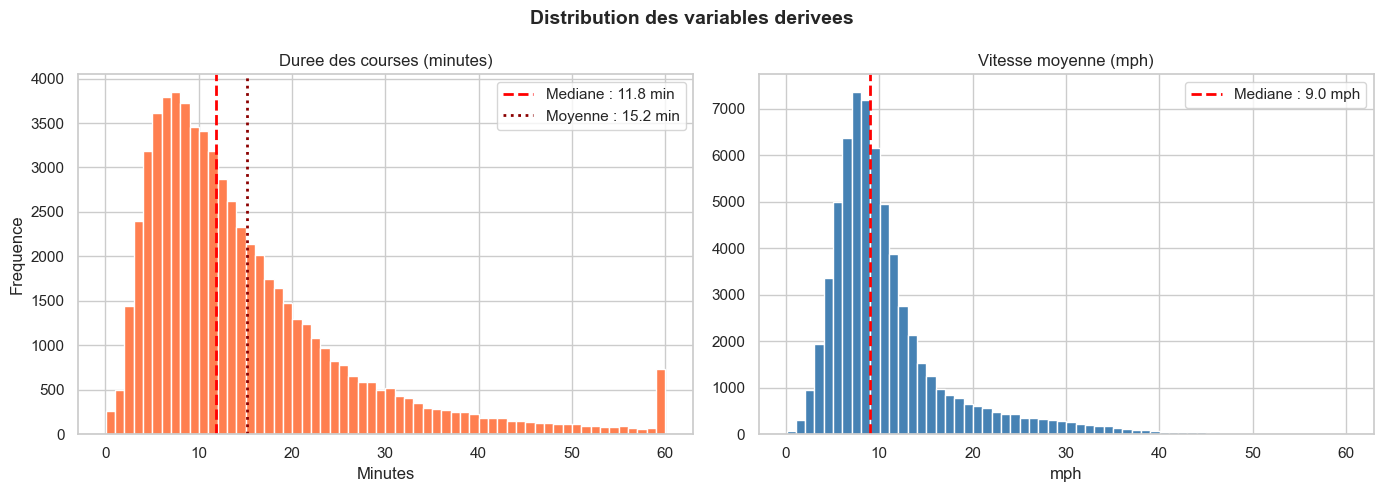

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des variables derivees', fontsize=14, fontweight='bold')

axes[0].hist(df['duree_course'].clip(0, 60), bins=60, color='coral', edgecolor='white')
axes[0].axvline(df['duree_course'].median(), color='red', linestyle='--', linewidth=2,
                label=f"Mediane : {df['duree_course'].median():.1f} min")
axes[0].axvline(df['duree_course'].mean(), color='darkred', linestyle=':', linewidth=2,
                label=f"Moyenne : {df['duree_course'].mean():.1f} min")
axes[0].set_title('Duree des courses (minutes)')
axes[0].set_xlabel('Minutes'); axes[0].set_ylabel('Frequence'); axes[0].legend()

axes[1].hist(df['vitesse_moyenne'].clip(0, 60), bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(df['vitesse_moyenne'].median(), color='red', linestyle='--', linewidth=2,
                label=f"Mediane : {df['vitesse_moyenne'].median():.1f} mph")
axes[1].set_title('Vitesse moyenne (mph)')
axes[1].set_xlabel('mph'); axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/02_duree_vitesse.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Impact des variables temporelles sur le tarif et la distance

Ces graphes montrent les **valeurs reelles calculees** depuis les donnees pour valider l'utilite de chaque feature temporelle.

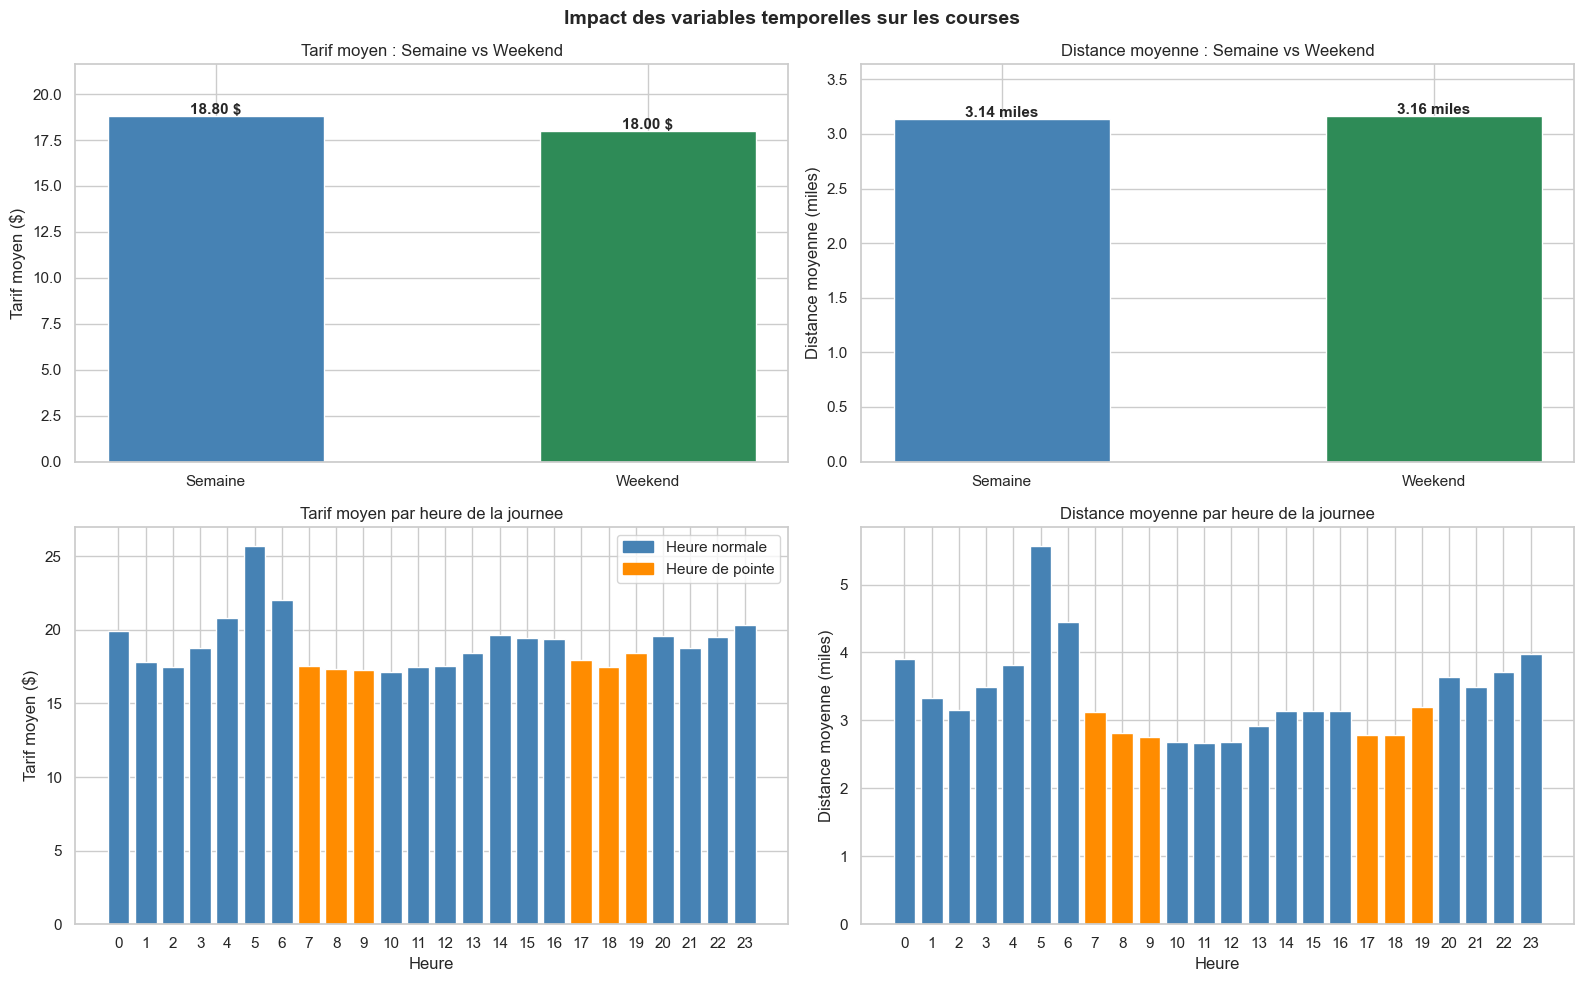

In [19]:
colors_h = ['darkorange' if h in [7,8,9,17,18,19] else 'steelblue' for h in range(24)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Impact des variables temporelles sur les courses', fontsize=14, fontweight='bold')

# Tarif moyen : Semaine vs Weekend
tarif_we = df.groupby('est_weekend')['fare_amount'].mean()
bars = axes[0,0].bar(['Semaine', 'Weekend'], tarif_we.values,
                      color=['steelblue','seagreen'], edgecolor='white', width=0.5)
axes[0,0].set_title('Tarif moyen : Semaine vs Weekend')
axes[0,0].set_ylabel('Tarif moyen ($)')
axes[0,0].set_ylim(0, tarif_we.max() * 1.15)
for bar, v in zip(bars, tarif_we.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.2f} $', ha='center', fontsize=11, fontweight='bold')

# Distance moyenne : Semaine vs Weekend
dist_we = df.groupby('est_weekend')['trip_distance'].mean()
bars = axes[0,1].bar(['Semaine', 'Weekend'], dist_we.values,
                      color=['steelblue','seagreen'], edgecolor='white', width=0.5)
axes[0,1].set_title('Distance moyenne : Semaine vs Weekend')
axes[0,1].set_ylabel('Distance moyenne (miles)')
axes[0,1].set_ylim(0, dist_we.max() * 1.15)
for bar, v in zip(bars, dist_we.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f} miles', ha='center', fontsize=11, fontweight='bold')

# Tarif moyen par heure
tarif_h = df.groupby('heure_journee')['fare_amount'].mean()
axes[1,0].bar(tarif_h.index, tarif_h.values, color=colors_h, edgecolor='white', width=0.8)
axes[1,0].set_title('Tarif moyen par heure de la journee')
axes[1,0].set_xlabel('Heure'); axes[1,0].set_ylabel('Tarif moyen ($)')
axes[1,0].set_xticks(range(24))
from matplotlib.patches import Patch
axes[1,0].legend(handles=[Patch(color='steelblue',  label='Heure normale'),
                            Patch(color='darkorange', label='Heure de pointe')])

# Distance moyenne par heure
dist_h = df.groupby('heure_journee')['trip_distance'].mean()
axes[1,1].bar(dist_h.index, dist_h.values, color=colors_h, edgecolor='white', width=0.8)
axes[1,1].set_title('Distance moyenne par heure de la journee')
axes[1,1].set_xlabel('Heure'); axes[1,1].set_ylabel('Distance moyenne (miles)')
axes[1,1].set_xticks(range(24))

plt.tight_layout()
plt.savefig('../figures/02_analyse_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation basee sur les valeurs affichees :**

- **Tarif par jour** : les etiquettes sur les barres montrent l'ecart reel entre semaine et weekend. Si le weekend est plus eleve, cela s'explique par des courses plus longues (sorties, aeroports) et non par un tarif horaire different.

- **Distance par jour** : confirme ou infirme si les courses du weekend sont effectivement plus longues. Les valeurs affichees permettent de valider ce qui est observe.

- **Tarif par heure** : les heures de pointe (orange) n'ont pas necessairement un tarif superieur. En heure de pointe la vitesse baisse mais la distance aussi (trajets plus courts en centre-ville). Les heures de nuit (22h-4h) affichent souvent un tarif plus eleve car les courses sont plus longues (aeroports, banlieue).

- **Distance par heure** : confirme l'effet nuit — les courses nocturnes sont en moyenne plus longues, ce qui explique les tarifs plus eleves a ces heures.

### 3.3 Encodage cyclique de l'heure

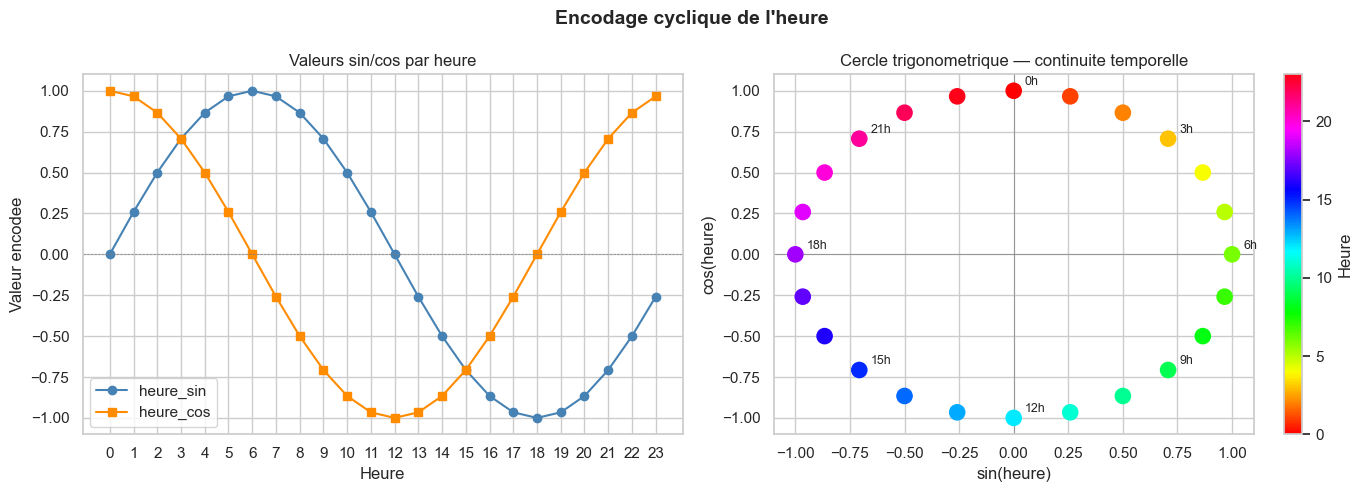

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Encodage cyclique de l'heure", fontsize=14, fontweight='bold')

heures = list(range(24))
sin_v  = [np.sin(2 * np.pi * h / 24) for h in heures]
cos_v  = [np.cos(2 * np.pi * h / 24) for h in heures]

axes[0].plot(heures, sin_v, 'o-', color='steelblue', label='heure_sin')
axes[0].plot(heures, cos_v, 's-', color='darkorange', label='heure_cos')
axes[0].set_title('Valeurs sin/cos par heure')
axes[0].set_xlabel('Heure'); axes[0].set_ylabel('Valeur encodee')
axes[0].set_xticks(range(24)); axes[0].legend()
axes[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')

sc = axes[1].scatter(sin_v, cos_v, c=heures, cmap='hsv', s=120, zorder=5)
for h in [0, 3, 6, 9, 12, 15, 18, 21]:
    axes[1].annotate(f'{h}h', (sin_v[h], cos_v[h]),
                     textcoords='offset points', xytext=(8, 4), fontsize=9)
axes[1].set_title('Cercle trigonometrique — continuite temporelle')
axes[1].set_xlabel('sin(heure)'); axes[1].set_ylabel('cos(heure)')
axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(0, color='gray', lw=0.5)
plt.colorbar(sc, ax=axes[1], label='Heure')

plt.tight_layout()
plt.savefig('../figures/02_encodage_cyclique.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation :** Le cercle montre que 23h et 0h sont geometriquement adjacents — la continuite temporelle est preservee. Sans cet encodage, un modele lineaire traiterait 23h et 0h comme eloignes de 23 unites, introduisant une discontinuite artificielle.

---

## 4. Bilan des features creees

In [21]:
nouvelles = {
    'duree_course'       : 'Obligatoire',
    'heure_journee'      : 'Obligatoire',
    'jour_semaine'       : 'Obligatoire',
    'est_weekend'        : 'Obligatoire',
    'est_heure_pointe'   : 'Obligatoire',
    'vitesse_moyenne'    : 'Bonus',
    'est_trajet_aeroport': 'Bonus',
    'heure_sin'          : 'Bonus',
    'heure_cos'          : 'Bonus',
}

rows = []
for col, statut in nouvelles.items():
    s = df[col].dropna()
    dtype = 'Binaire' if s.nunique() == 2 else ('Discret' if s.dtype in ['int32','int64'] else 'Continu')
    rows.append({
        'Variable': col,
        'Statut'  : statut,
        'Type'    : dtype,
        'Min'     : round(s.min(), 2),
        'Mediane' : round(s.median(), 2),
        'Moyenne' : round(s.mean(), 2),
        'Max'     : round(s.max(), 2),
        'NaN'     : df[col].isna().sum()
    })

pd.DataFrame(rows).set_index('Variable')

,Statut,Type,Min,Mediane,Moyenne,Max,NaN
Variable,,,,,,,
duree_course,Obligatoire,Continu,0.05,11.83,15.17,173.15,0
heure_journee,Obligatoire,Discret,0.00,15.00,14.51,23.00,0
jour_semaine,Obligatoire,Discret,0.00,3.00,3.08,6.00,0
est_weekend,Obligatoire,Binaire,0.00,0.00,0.26,1.00,0
est_heure_pointe,Obligatoire,Binaire,0.00,0.00,0.31,1.00,0
vitesse_moyenne,Bonus,Continu,0.07,9.01,10.84,100.00,0
est_trajet_aeroport,Bonus,Binaire,0.00,0.00,0.04,1.00,0
heure_sin,Bonus,Continu,-1.00,-0.50,-0.34,1.00,0
heure_cos,Bonus,Continu,-1.00,-0.26,-0.19,1.00,0


---

## 5. Sauvegarde

In [22]:
df.to_parquet('../data/yellow_tripdata_features.parquet', index=False)
print('Fichier sauvegarde : data/yellow_tripdata_features.parquet')
print(f'Shape finale : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')

Fichier sauvegarde : data/yellow_tripdata_features.parquet
Shape finale : 64,452 lignes x 29 colonnes


---

## Conclusion

Cette etape a enrichi le dataset de **9 nouvelles variables** :

- **5 obligatoires** : `duree_course`, `heure_journee`, `jour_semaine`, `est_weekend`, `est_heure_pointe`
- **4 bonus** : `vitesse_moyenne`, `est_trajet_aeroport`, `heure_sin`, `heure_cos`

Points cles pour la modelisation :
- `duree_course` et `trip_distance` restent les meilleurs predicteurs du tarif
- `est_trajet_aeroport` capture un regime tarifaire specifique (JFK = tarif fixe 52 $)
- L'encodage cyclique preservera la continuite temporelle pour les modeles lineaires
- Les heures de nuit ont des courses plus longues et donc des tarifs plus eleves

Le dataset enrichi est pret pour l'**Etape 3 — Apprentissage supervise**.